Retrieval Similarity for all 4 subsets combined for CLIP

Drive Embeddings Structure:

MMRetrieval/embeddings/

&emsp; &emsp; subset1_image_embeddings.npy <br>
&emsp; &emsp; subset1_caption_embeddings.npy<br>

&emsp; &emsp; subset2_image_embeddings.npy<br>
&emsp; &emsp; subset2_caption_embeddings.npy<br>

&emsp; &emsp; subset3_image_embeddings.npy<br>
&emsp; &emsp; subset3_caption_embeddings.npy<br>

&emsp; &emsp; subset4_image_embeddings.npy<br>
&emsp; &emsp; subset4_caption_embeddings.npy<br>

In [ ]:
import numpy as np
import pandas as pd
import pickle
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(os.listdir("/content/drive/MyDrive/MMRetrieval/embeddings"))

['subset1_caption_embeddings.npy', 'subset1_image_embeddings.npy', 'subset1_image_ids.pkl', 'subset1_metadata.csv', 'subset2_image_embeddings.npy', 'subset2_caption_embeddings.npy', 'subset2_metadata.csv', 'subset2_image_ids.pkl', 'subset4_image_embeddings.npy', 'subset4_caption_embeddings.npy', 'subset4_image_ids.pkl', 'subset4_metadata.csv', 'subset3_image_embeddings.npy', 'subset3_caption_embeddings.npy', 'subset3_image_ids.pkl', 'subset3_metadata.csv']


In [ ]:
#Load all 4 embeddings

img1 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset1_image_embeddings.npy")
img2 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset2_image_embeddings.npy")
img4 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset4_image_embeddings.npy")
img3 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset3_image_embeddings.npy")


cap1 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset1_caption_embeddings.npy")
cap2 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset2_caption_embeddings.npy")
cap4 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset4_caption_embeddings.npy")
cap3 = np.load("/content/drive/MyDrive/MMRetrieval/embeddings/subset3_caption_embeddings.npy")


In [ ]:
# Combine embeddings
image_embeddings = np.vstack(
    [img1, img2, img3, img4]
)

caption_embeddings = np.vstack(
    [cap1, cap2, cap3, cap4]
)

print(image_embeddings.shape)
print(caption_embeddings.shape)

(8091, 512)
(40455, 512)


In [ ]:
# Combine metadata

m1 = pd.read_csv("/content/drive/MyDrive/MMRetrieval/embeddings/subset1_metadata.csv")
m2 = pd.read_csv("/content/drive/MyDrive/MMRetrieval/embeddings/subset2_metadata.csv")
m3 = pd.read_csv("/content/drive/MyDrive/MMRetrieval/embeddings/subset3_metadata.csv")
m4 = pd.read_csv("/content/drive/MyDrive/MMRetrieval/embeddings/subset4_metadata.csv")

metadata = pd.concat(
    [m1, m2, m3, m4],
    ignore_index=True
)

# Load image id
image_ids = []

for file in [
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_image_ids.pkl",
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_image_ids.pkl",
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset3_image_ids.pkl",
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset4_image_ids.pkl",
    # "subset4_image_ids.pkl"
]:
    with open(file, "rb") as f:
        image_ids.extend(
            pickle.load(f)
        )

In [ ]:
print(len(image_ids))
print(metadata.shape)

8091
(40455, 2)


In [ ]:
# Create a similarity matrix
similarity_matrix = (
    image_embeddings @ caption_embeddings.T
)

text_to_image_matrix = (
    caption_embeddings @ image_embeddings.T
)

text_similarity = (
    caption_embeddings @ caption_embeddings.T
)

print(similarity_matrix.shape)
print(text_to_image_matrix.shape)
print(text_similarity.shape)

(8091, 40455)
(40455, 8091)
(40455, 40455)


In [ ]:
#ground truth
from collections import defaultdict

image_to_captions = defaultdict(list)

for idx, row in metadata.iterrows():
    image_to_captions[row["image"]].append(idx)

image_to_idx = {
    img: idx
    for idx, img in enumerate(image_ids)
}

caption_to_image = []

for _, row in metadata.iterrows():
    caption_to_image.append(
        image_to_idx[row["image"]]
    )

In [ ]:
# image to text
r1 = r5 = r10 = 0
rr = []

for img_idx, img_name in enumerate(image_ids):

    gt = set(
        image_to_captions[img_name]
    )

    ranked = np.argsort(
        similarity_matrix[img_idx]
    )[::-1]

    first_rank = None

    for rank, cap_idx in enumerate(
        ranked,
        start=1
    ):
        if cap_idx in gt:
            first_rank = rank
            break

    rr.append(1 / first_rank)

    if first_rank <= 1:
        r1 += 1

    if first_rank <= 5:
        r5 += 1

    if first_rank <= 10:
        r10 += 1

n = len(image_ids)

i2t_results = {
    "Recall@1": r1/n,
    "Recall@5": r5/n,
    "Recall@10": r10/n,
    "MRR": np.mean(rr)
}

print(i2t_results)

{'Recall@1': 0.47015202076381163, 'Recall@5': 0.7018909899888766, 'Recall@10': 0.7864293659621802, 'MRR': np.float64(0.5769681499546749)}


In [ ]:
# text to image
r1 = r5 = r10 = 0
rr = []

for cap_idx in range(len(caption_to_image)):

    gt_img = caption_to_image[cap_idx]

    ranked = np.argsort(
        text_to_image_matrix[cap_idx]
    )[::-1]

    rank = (
        np.where(
            ranked == gt_img
        )[0][0]
        + 1
    )

    rr.append(1/rank)

    if rank <= 1:
        r1 += 1

    if rank <= 5:
        r5 += 1

    if rank <= 10:
        r10 += 1

n = len(caption_to_image)

t2i_results = {
    "Recall@1": r1/n,
    "Recall@5": r5/n,
    "Recall@10": r10/n,
    "MRR": np.mean(rr)
}

print(t2i_results)

{'Recall@1': 0.29828204177481155, 'Recall@5': 0.5329131133358053, 'Recall@10': 0.632406377456433, 'MRR': np.float64(0.4103921510921051)}


In [ ]:
# Results

results = pd.DataFrame({
    "Metric":[
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR"
    ],
    "Image→Text":[
        i2t_results["Recall@1"],
        i2t_results["Recall@5"],
        i2t_results["Recall@10"],
        i2t_results["MRR"]
    ],
    "Text→Image":[
        t2i_results["Recall@1"],
        t2i_results["Recall@5"],
        t2i_results["Recall@10"],
        t2i_results["MRR"]
    ]
})

results

,Metric,Image→Text,Text→Image
0,Recall@1,0.470152,0.298282
1,Recall@5,0.701891,0.532913
2,Recall@10,0.786429,0.632406
3,MRR,0.576968,0.410392


Qualitative

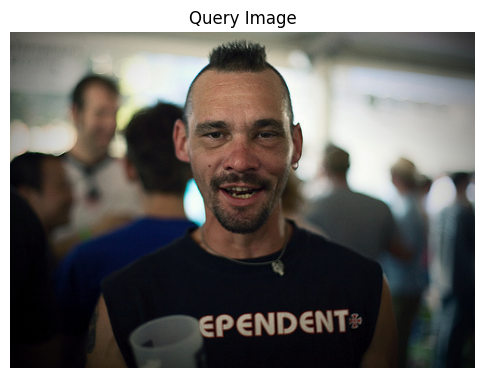

GROUND TRUTH CAPTIONS
- A male wearing a blue shirt is holding a cup in hand while staring at the camera .
- A man in a short Mohawk and beard .
- A man with a Mohawk and a shirt saying " -ependent " faces the camera
- A man with a Mohawk is holding a cup .
- A man with a Mohawk smiles at the camera .


TOP-5 RETRIEVED CAPTIONS

Top-1
Score: 0.3504
A man with a Mohawk and a shirt saying " -ependent " faces the camera

Top-2
Score: 0.3047
A man with a Mohawk smiles at the camera .

Top-3
Score: 0.2852
A man with a many colored Mohawk smiling .

Top-4
Score: 0.2776
A man wearing a Barack Obama shirt smiles for the camera

Top-5
Score: 0.2772
A person with a colorful Mohawk and tank top smiling .


In [ ]:
# image to text
from PIL import Image
import matplotlib.pyplot as plt
import random

IMAGE_DIR = "/content/drive/MyDrive/MMRetrieval/flickr8k/Images"

image_idx = random.randint(
    0,
    len(image_ids)-1
)

img_name = image_ids[image_idx]

img = Image.open(
    f"{IMAGE_DIR}/{img_name}"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

print("="*100)
print("GROUND TRUTH CAPTIONS")
print("="*100)

for idx in image_to_captions[img_name]:
    print("-", metadata.iloc[idx]["caption"])

scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

print("\n")
print("="*100)
print("TOP-5 RETRIEVED CAPTIONS")
print("="*100)

for rank, cap_idx in enumerate(top5, start=1):

    print(f"\nTop-{rank}")
    print("Score:", round(scores[cap_idx],4))
    print(metadata.iloc[cap_idx]["caption"])

QUERY CAPTION
Three people are walking down the street with cars and buildings in the background .


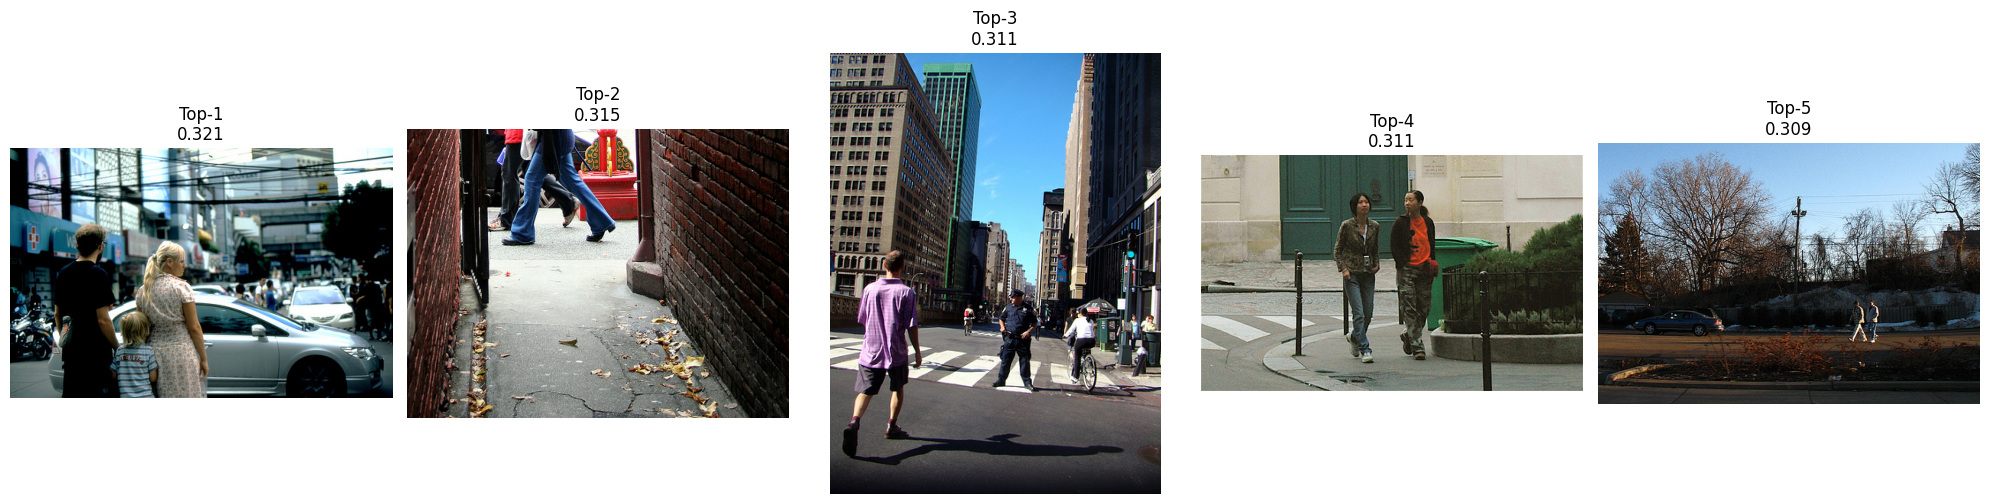

In [ ]:
# text to image

caption_idx = random.randint(
    0,
    len(metadata)-1
)

query_caption = metadata.iloc[
    caption_idx
]["caption"]

print("="*100)
print("QUERY CAPTION")
print("="*100)
print(query_caption)

scores = text_to_image_matrix[
    caption_idx
]

top5 = scores.argsort()[-5:][::-1]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,5)
)

for i, img_idx in enumerate(top5):

    img_name = image_ids[img_idx]

    img = Image.open(
        f"{IMAGE_DIR}/{img_name}"
    )

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(
        f"Top-{i+1}\n{scores[img_idx]:.3f}"
    )

plt.tight_layout()
plt.show()

In [ ]:
# text to text
query_idx = random.randint(
    0,
    len(metadata)-1
)

scores = text_similarity[
    query_idx
].copy()

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("="*100)
print("QUERY")
print("="*100)

print(
    metadata.iloc[query_idx]["caption"]
)

print("\n")
print("="*100)
print("TOP-5 RETRIEVED")
print("="*100)

for rank, idx in enumerate(top5, start=1):

    print(f"\nTop-{rank}")
    print(
        "Score:",
        round(scores[idx],4)
    )
    print(
        metadata.iloc[idx]["caption"]
    )

QUERY
A monk in a red shawl looks at the camera


TOP-5 RETRIEVED

Top-1
Score: 0.7864
A man dressed in a red outfit .

Top-2
Score: 0.7743
The child in the red coat laid in the red mat .

Top-3
Score: 0.7692
a boy wears a red coat .

Top-4
Score: 0.767
A man in red winter clothes talks to another man in red .

Top-5
Score: 0.7548
An asian lady in a red jacket taking a photo
